In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/paysim.csv')

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/paysim.csv'

In [2]:
import os

print("Current folder:", os.getcwd())
print("\nFiles in data/raw:", os.listdir('../data/raw'))

Current folder: C:\Users\LENOVO\Downloads\upi-shield


FileNotFoundError: [WinError 3] The system cannot find the path specified: '../data/raw'

In [3]:
print("Files in data/raw:", os.listdir('data/raw'))

Files in data/raw: ['paysim.csv.csv']


In [4]:
import pandas as pd

df = pd.read_csv('data/raw/paysim.csv.csv')

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (6362620, 11)

Data types:
 step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Missing values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate rows: 0


In [5]:
import matplotlib.pyplot as plt

fraud_counts = df['isFraud'].value_counts()
print(fraud_counts)
print(f"\nFraud percentage: {fraud_counts[1] / len(df) * 100:.3f}%")
"
plt.figure(figsize=(6,4))
fraud_counts.plot(kind='bar', color=['steelblue', 'crimson'])
plt.xticks([0,1], ['Normal', 'Fraud'], rotation=0)
plt.title('Transaction Class Distribution')
plt.ylabel('Count')
plt.show()"

SyntaxError: unterminated string literal (detected at line 6) (4247514547.py, line 6)

isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud percentage: 0.129


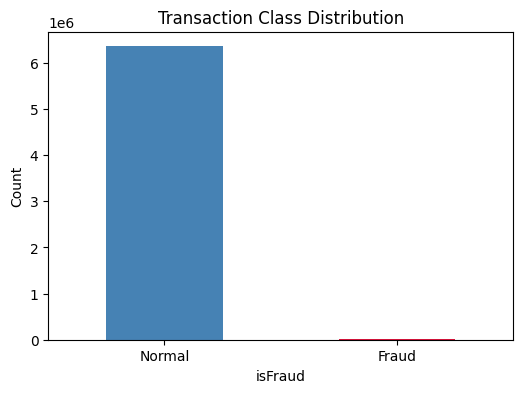

In [6]:
import matplotlib.pyplot as plt

fraud_counts = df['isFraud'].value_counts()
print(fraud_counts)

fraud_pct = fraud_counts[1] / len(df) * 100
print('Fraud percentage:', round(fraud_pct, 3))

plt.figure(figsize=(6,4))
fraud_counts.plot(kind='bar', color=['steelblue', 'crimson'])
plt.xticks([0,1], ['Normal', 'Fraud'], rotation=0)
plt.title('Transaction Class Distribution')
plt.ylabel('Count')
plt.show()

            count   sum
type                   
CASH_IN   1399284     0
CASH_OUT  2237500  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   532909  4097


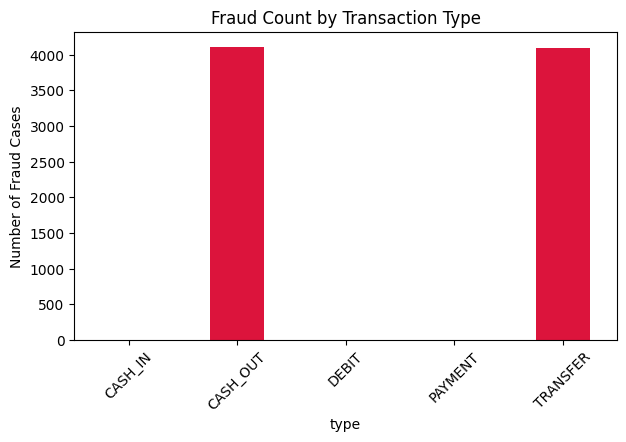

In [7]:
print(df.groupby('type')['isFraud'].agg(['count', 'sum']))

plt.figure(figsize=(7,4))
df.groupby('type')['isFraud'].sum().plot(kind='bar', color='crimson')
plt.title('Fraud Count by Transaction Type')
plt.ylabel('Number of Fraud Cases')
plt.xticks(rotation=45)
plt.show()

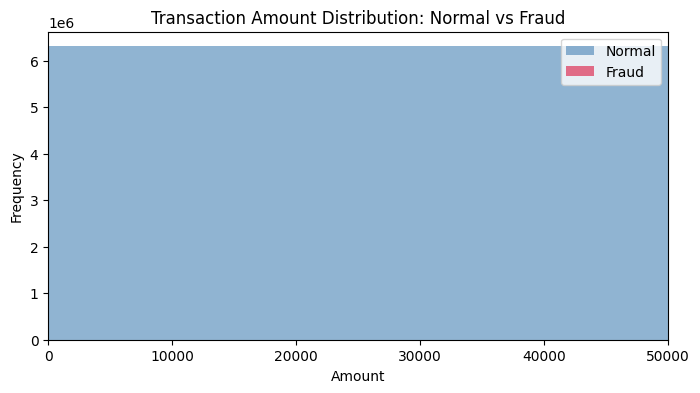

In [8]:
plt.figure(figsize=(8,4))
df[df['isFraud']==0]['amount'].plot(kind='hist', bins=50, alpha=0.6, label='Normal', color='steelblue')
df[df['isFraud']==1]['amount'].plot(kind='hist', bins=50, alpha=0.6, label='Fraud', color='crimson')
plt.legend()
plt.title('Transaction Amount Distribution: Normal vs Fraud')
plt.xlabel('Amount')
plt.xlim(0, 50000)
plt.show()

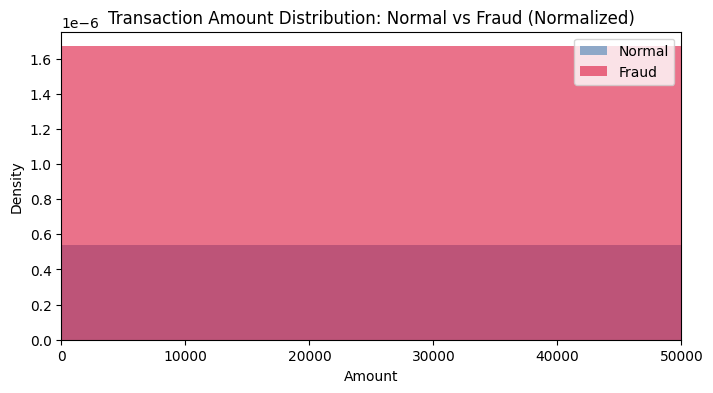

In [9]:
plt.figure(figsize=(8,4))
df[df['isFraud']==0]['amount'].plot(kind='hist', bins=50, alpha=0.6, label='Normal', color='steelblue', density=True)
df[df['isFraud']==1]['amount'].plot(kind='hist', bins=50, alpha=0.6, label='Fraud', color='crimson', density=True)
plt.legend()
plt.title('Transaction Amount Distribution: Normal vs Fraud (Normalized)')
plt.xlabel('Amount')
plt.ylabel('Density')
plt.xlim(0, 50000)
plt.show()


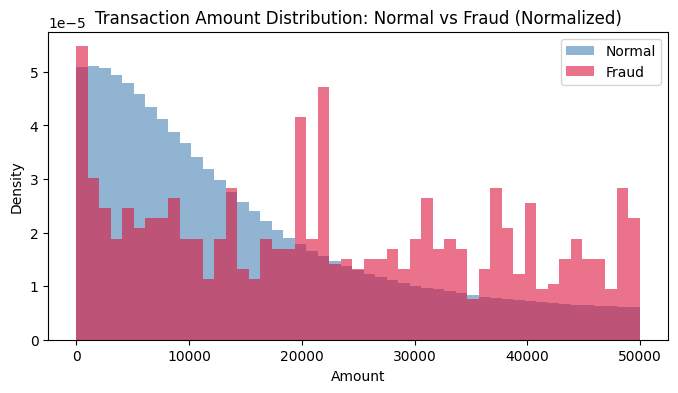

In [10]:
import numpy as np

bins = np.linspace(0, 50000, 50)

plt.figure(figsize=(8,4))
plt.hist(df[df['isFraud']==0]['amount'], bins=bins, alpha=0.6, label='Normal', color='steelblue', density=True)
plt.hist(df[df['isFraud']==1]['amount'], bins=bins, alpha=0.6, label='Fraud', color='crimson', density=True)
plt.legend()
plt.title('Transaction Amount Distribution: Normal vs Fraud (Normalized)')
plt.xlabel('Amount')
plt.ylabel('Density')
plt.show()